In [1]:
print("Step 1: Importing libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os
import joblib
import time
from wordcloud import WordCloud
from itertools import product

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style('whitegrid')
print("Libraries imported successfully.\n")


Step 1: Importing libraries...
Libraries imported successfully.



In [2]:
# Step 2: Mount Google Drive and Load Data
print("Step 2: Loading preprocessed data from Google Drive...")
try:
    if not os.path.isdir('/content/drive/My Drive'):
        drive.mount('/content/drive')
    file_path = '/content/drive/MyDrive/AIML assignment/results/preprocessed_reviews.csv' # IMPORTANT: Update this path
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found at '{file_path}'. Please check the path.")
    df = pd.read_csv(file_path)
    df.dropna(subset=['review', 'sentiment'], inplace=True)
    print("Dataset loaded successfully.")
except Exception as e:
    print(f"An error occurred: {e}")



Step 2: Loading preprocessed data from Google Drive...
Dataset loaded successfully.


In [3]:
# Step 3: Feature Extraction and Data Splitting
print("\nStep 3: Vectorizing text and splitting data...")
df['review'].fillna('', inplace=True)
vectorizer = TfidfVectorizer(max_features=5000)
X_sparse = vectorizer.fit_transform(df['review'])
y = df['sentiment'].values
X_dense = X_sparse.toarray()

X_train, X_test, y_train, y_test = train_test_split(X_dense, y, test_size=0.2, random_state=42, stratify=y)
# Create a validation set from the training set for hyperparameter tuning
X_train_part, X_val, y_train_part, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"Training partition shape: {X_train_part.shape}")
print(f"Validation partition shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}\n")



Step 3: Vectorizing text and splitting data...


/tmp/ipython-input-833647085.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review'].fillna('', inplace=True)


Training partition shape: (32000, 5000)
Validation partition shape: (8000, 5000)
Test set shape: (10000, 5000)



In [4]:
# Step 4: Manual Hyperparameter Tuning
print("Step 4: Performing Manual Hyperparameter Tuning...")

# Define the hyperparameter grid
param_grid = {
    'neurons': [64, 128],
    'dropout_rate': [0.3, 0.5],
    'optimizer': ['adam', 'rmsprop']
}

# Function to create the model
def create_tunable_model(input_dim, neurons=128, dropout_rate=0.5, optimizer='adam'):
    model = Sequential([
        Dense(neurons, activation='relu', input_shape=(input_dim,)),
        Dropout(dropout_rate),
        Dense(neurons // 2, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

best_score = -1
best_params = {}
all_results = []

# Manually iterate through all parameter combinations
param_combinations = list(product(*param_grid.values()))

for i, params in enumerate(param_combinations):
    current_params = dict(zip(param_grid.keys(), params))
    print(f"--- Tuning {i+1}/{len(param_combinations)}: {current_params} ---")

    # Create and train the model with the current parameters
    model = create_tunable_model(X_train_part.shape[1], **current_params)
    model.fit(X_train_part, y_train_part, epochs=8, batch_size=128, verbose=0)

    # Evaluate on the validation set
    score = model.evaluate(X_val, y_val, verbose=0)[1] # [1] is the accuracy
    print(f"Validation Accuracy: {score:.4f}")

    all_results.append({'params': current_params, 'accuracy': score})

    # Check if this is the best model so far
    if score > best_score:
        best_score = score
        best_params = current_params

print(f"\nManual tuning complete.")
print(f"Best validation accuracy: {best_score:.4f}")
print(f"Best parameters found: {best_params}")

Step 4: Performing Manual Hyperparameter Tuning...
--- Tuning 1/8: {'neurons': 64, 'dropout_rate': 0.3, 'optimizer': 'adam'} ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.8746
--- Tuning 2/8: {'neurons': 64, 'dropout_rate': 0.3, 'optimizer': 'rmsprop'} ---
Validation Accuracy: 0.8817
--- Tuning 3/8: {'neurons': 64, 'dropout_rate': 0.5, 'optimizer': 'adam'} ---
Validation Accuracy: 0.8805
--- Tuning 4/8: {'neurons': 64, 'dropout_rate': 0.5, 'optimizer': 'rmsprop'} ---
Validation Accuracy: 0.8865
--- Tuning 5/8: {'neurons': 128, 'dropout_rate': 0.3, 'optimizer': 'adam'} ---
Validation Accuracy: 0.8752
--- Tuning 6/8: {'neurons': 128, 'dropout_rate': 0.3, 'optimizer': 'rmsprop'} ---
Validation Accuracy: 0.8813
--- Tuning 7/8: {'neurons': 128, 'dropout_rate': 0.5, 'optimizer': 'adam'} ---
Validation Accuracy: 0.8804
--- Tuning 8/8: {'neurons': 128, 'dropout_rate': 0.5, 'optimizer': 'rmsprop'} ---
Validation Accuracy: 0.8835

Manual tuning complete.
Best validation accuracy: 0.8865
Best parameters found: {'neurons': 64, 'dropout_rate': 0.5, 'optimizer': 'rmsprop'}



Step 5: Training the final model with best parameters and early stopping...
Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7187 - loss: 0.5716 - val_accuracy: 0.8847 - val_loss: 0.2792
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8911 - loss: 0.2826 - val_accuracy: 0.8892 - val_loss: 0.2649
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9081 - loss: 0.2466 - val_accuracy: 0.8883 - val_loss: 0.2689
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9175 - loss: 0.2225 - val_accuracy: 0.8871 - val_loss: 0.2800
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9245 - loss: 0.2108 - val_accuracy: 0.8864 - val_loss: 0.2840

Final Tuned Model Accuracy on Test Set: 0.8892 (88.92%)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Final Model Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.89      5000
    Positive       0.89      0.89  

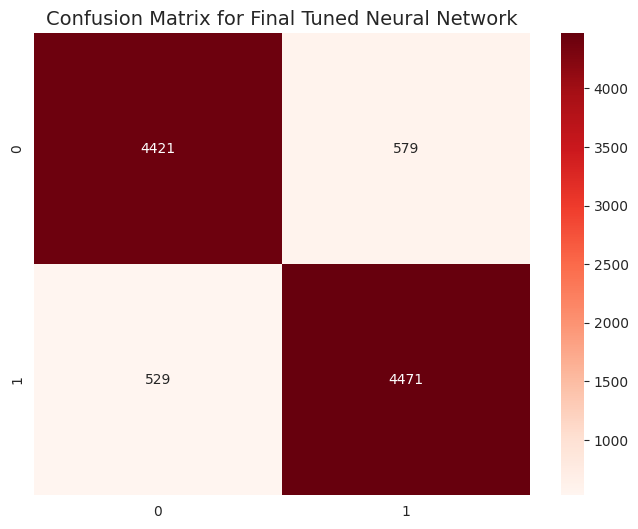

In [5]:
# Step 5: Final Model Training
print("\nStep 5: Training the final model with best parameters and early stopping...")

final_model = create_tunable_model(X_train.shape[1], **best_params)

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_final = final_model.fit(
    X_train, y_train, # Train on the full training set
    epochs=25,
    batch_size=128,
    validation_data=(X_test, y_test), # Use test set for validation curve
    callbacks=[early_stopping],
    verbose=1
)

final_loss, final_accuracy = final_model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Tuned Model Accuracy on Test Set: {final_accuracy:.4f} ({final_accuracy:.2%})")

y_pred_final_prob = final_model.predict(X_test)
y_pred_final = (y_pred_final_prob > 0.5).astype(int).flatten()

print("\nFinal Model Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Negative', 'Positive']))

print("\nFinal Model Confusion Matrix:")
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix for Final Tuned Neural Network', fontsize=14)
plt.show()


In [6]:
# Step 6: Save the Model and Results
print("\nStep 6: Saving the model, vectorizer, and results...")
results_dir = '/content/drive/MyDrive/AIML assignment/results/neural_network_results'
os.makedirs(results_dir, exist_ok=True)

final_model.save(os.path.join(results_dir, 'neural_network_model.keras'))
joblib.dump(vectorizer, os.path.join(results_dir, 'tfidf_vectorizer.pkl'))

report_df = pd.DataFrame(classification_report(y_test, y_pred_final, output_dict=True)).transpose()
report_df.to_csv(os.path.join(results_dir, 'classification_report.csv'))

with open(os.path.join(results_dir, 'accuracy.txt'), 'w') as f:
    f.write(f'Final Tuned Model Accuracy: {final_accuracy:.4f}\n')
    f.write(f'Best Parameters: {best_params}\n')

print(f"\nAll results have been saved to {results_dir}")


Step 6: Saving the model, vectorizer, and results...

All results have been saved to /content/drive/MyDrive/AIML assignment/results/neural_network_results
